In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

False

In [2]:
headers = {
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                        "(KHTML, like Gecko) Chrome/141.0.0.0 Safari/537.36"
        }

In [3]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin 

def extract_html_and_media_urls(url):
    """Extracts HTML content and media (images and videos) URLs from a given URL."""
    try:
        response = requests.get(url, headers=headers)
        response.raise_for_status()
        
        #Parse the HTML content
        soup = BeautifulSoup(response.text, 'html.parser')
        
        #Extract HTML
        html_content = soup.prettify()
        
        #Extract image URLs
        images = [urljoin(url, img['src']) for img in soup.find_all('img') if 'src' in img.attrs]
        
        #Extract video URLs
        videos = [urljoin(url, video['src']) for video in soup.find_all('video') if 'src' in video.attrs]
        
        return html_content, images, videos
    except requests.RequestException as e:
        return f"An error occured: {e}", [], []
        

In [4]:
url = "https://vi.wikipedia.org/wiki/V%C4%83n_Mi%E1%BA%BFu_%E2%80%93_Qu%E1%BB%91c_T%E1%BB%AD_Gi%C3%A1m"
html_content, images, videos = extract_html_and_media_urls(url)

In [5]:
r = requests.get(url, headers=headers)
print(r.status_code)
print(r.text[:1000])

200
<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 vector-feature-night-mode-enabled skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available" lang="vi" dir="ltr">
<head>
<meta charset="UTF-8">
<title>Văn Miếu – Quốc Tử Giám – Wikipedia tiếng Việt</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-con

In [6]:
import tiktoken

def num_tokens_from_string(string: str, encoding_name: str) -> int:
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens

In [7]:
print("HTML Number of Tokens:", num_tokens_from_string(html_content, "cl100k_base"))
print("Number of Image URLs:", len(images))

HTML Number of Tokens: 106808
Number of Image URLs: 30


# Setup Model

In [4]:
import torch
import ollama 
from openai import OpenAI

In [ ]:
client = OpenAI(
    base_url='http://localhost:11434/v1',
    api_key='llama3'
)

In [6]:
deployment = "llama3.1:8b"

In [7]:
def run_llama_cleaning(html_content: str) -> str:
    system_prompt = """
    You are a text cleaner.
    Your task is to take HTML content and return ONLY the plain text content in markdown format.
    Do NOT add any HTML, CSS, JavaScript, or explanation.
    Do NOT summarize or analyze the content.
    Remove all HTML tags but keep the text in the same order.
    The output must be **only the cleaned text in markdown**.
    
    Example:
    Input: <p>Hello <b>World</b></p>
    Output: Hello World
    """

    response = client.chat.completions.create(
        model=deployment,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": html_content},
        ],
        temperature=0
    )
    print(f"{response.choices[0].message.role}: {response.choices[0].message.content}")
    return response.choices[0].message.content

In [1]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

def text_splitter(data, chunk_size, chunk_overlap):
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
    )
    chunks = text_splitter.split_documents(data)
    return chunks

In [ ]:
def save_content(url_string, html_content, markdown_content):
    """
    Saves HTML and Markdown content into separate files within a directory named after the given URL.

    Parameters:
    - url_string: The URL string used to name the directory.
    - html_content: The HTML content to be saved.
    - markdown_content: The Markdown content to be saved.
    """
    def create_directory_from_url(url):
        for protocol in ['http://', 'https://']:
            url = url.replace(protocol, '')
        forbidden_chars = ['/', '\\', ':', '*', '?', '"', '<', '>', '|']
        for char in forbidden_chars:
            url = url.replace(char, '_')
        return url

    directory_path = os.path.join('data', create_directory_from_url(url_string))
    
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)
        
    html_file_path = os.path.join(directory_path, 'content.html')
    with open(html_file_path, 'w', encoding='utf-8') as file:
        file.write(html_content)
        
    markdown_file_path = os.path.join(directory_path, 'content.md')
    with open(markdown_file_path, 'w', encoding='utf-8') as file:
        file.write(markdown_content)
    
    print(f"Files saved in {directory_path}")

In [9]:
from urllib.parse import urljoin, urlparse 
from langchain.docstore.document import Document

def is_valid_url(url):
    parsed = urlparse(url)
    return bool(parsed.netloc) and bool(parsed.scheme)

def get_links(url, session):
    try:
        response = session.get(url, timeout=5)
        response.raise_for_status()
        
        soup = BeautifulSoup(response.text, 'html.parser')
        links = [urljoin(url, link.get('href')) for link in soup.find_all('a', href=True)]
        return set(filter(is_valid_url, links))
    except requests.RequestException as e:
        print(f"Error accessing {url}: {e}")
        return set()
    
def scrape_site(root_url, max_depth=3, max_links=100):
    session = requests.Session()
    session.headers.update(headers)
    visited = set()
    
    def _scrape(url, depth):
        if url in visited or depth > max_depth or len(visited) >= max_links:
            return 
        visited.add(url)
        print(f"Visiting: {url} | Depth: {depth} | Total Visited: {len(visited)}")
        print(f"Processing: {url}")
        html_content, _, _ = extract_html_and_media_urls(url)
        doc = Document(page_content=html_content, metadata={"destination": "Văn miếu Quốc Tử Giám", "province": "Hà Nội", "type": "di tích lịch sử"})
        chunks = text_splitter([doc], 4000, 0)
        processed_content = ""
        for chunk in chunks:
            md_content = run_llama_cleaning(chunk.page_content)
            processed_content += md_content + "\n\n"
        save_content(url, html_content, processed_content)
        
        links = get_links(url, session)
        for link in links:
            _scrape(link, depth + 1)
            
    _scrape(root_url, 0)

In [ ]:
scrape_site(url, max_depth=3, max_links=1)

# Setup AI Search

In [ ]:
from langchain.document_loaders import TextLoader
from langchain.docstore.document import Document

loader = TextLoader("data/vi.wikipedia.org_wiki_V%C4%83n_Mi%E1%BA%BFu_%E2%80%93_Qu%E1%BB%91c_T%E1%BB%AD_Gi%C3%A1m/content.md")
docs = loader.load()

for i, doc in enumerate(docs):
    doc.page_content = doc.page_content.strip()
    new_metadata = doc.metadata.copy()  
    new_metadata.update({
        "destination": "Văn miếu Quốc Tử Giám", "province": "Hà Nội", "type": "di tích lịch sử"
    })
    docs[i] = Document(page_content=doc.page_content, metadata=new_metadata)

In [101]:
chunks = text_splitter(docs, 2048, 20)

In [12]:
print(chunks[0])

page_content='"Quốc Tử Giám" đổi hướng tới đây. Đối với các định nghĩa khác, xem Quốc Tử Giám (định hướng).' metadata={'source': 'data/vi.wikipedia.org_wiki_V%C4%83n_Mi%E1%BA%BFu_%E2%80%93_Qu%E1%BB%91c_T%E1%BB%AD_Gi%C3%A1m/content.md', 'destination': 'Văn miếu Quốc Tử Giám', 'province': 'Hà Nội', 'type': 'di tích lịch sử'}


## Create embedding model

In [104]:
from langchain.vectorstores import Chroma
from langchain_community.embeddings import OllamaEmbeddings
import chromadb
from chromadb.utils.embedding_functions import OllamaEmbeddingFunction

embeddings = OllamaEmbeddings(
    model="mxbai-embed-large"
)

client = chromadb.Client()

client.delete_collection("Van_mieu_Quoc_Tu_Giam")

documents = [doc.page_content for doc in chunks]
metadatas = [doc.metadata for doc in chunks]
ids = [str(i) for (i, _) in enumerate(chunks)]
# vectors = [embeddings.embed_query(text) for text in documents]

collection = client.create_collection(
    name="Van_mieu_Quoc_Tu_Giam",
    configuration={
        "hnsw": {"space": "cosine"},
        "embedding_function": OllamaEmbeddingFunction(model_name="mxbai-embed-large")
    }
)

collection.add(
    documents=documents,
    metadatas=metadatas,
    ids=ids
)

vectordb = Chroma(
    client=client,
    collection_name="Van_mieu_Quoc_Tu_Giam",
    embedding_function=embeddings,
)

# vectordb = Chroma.from_documents(chunks, embedding=embeddings)

In [2]:
import chromadb

client = chromadb.Client()

# Lấy danh sách tất cả collection hiện tại
all_collections = client.list_collections()
for col in all_collections:
    print(col.name)
    client.delete_collection(col.name)

In [105]:
retriever = vectordb.as_retriever(
    search_kwargs={"k": 5}
)

In [65]:
results = collection.query(query_texts=["Văn miếu được xây dựng từ năm nào?"])
results

{'ids': [['34', '45', '87', '20', '6', '85', '97', '46', '51', '80']],
 'embeddings': None,
 'documents': [['Hồ Văn hay hồ Giám phía trước cổng vào Văn Miếu.',
   'Văn miếu môn, cổng dẫn vào khu thứ nhất',
   'Lời thơ vua Quang Trung ở Văn Miếu - Quốc Tử Giám',
   'Kiến trúc quần thể Văn Miếu - Quốc Tử Giám ngày nay',
   'Văn miếu được xây dựng từ năm 1070, tức năm Thần Vũ thứ hai đời Lý Thánh Tông. Đại Việt sử ký toàn thư, Nxb. Khoa học xã hội, Hà Nội, tập 1, tr.234 chép: "Mùa thu tháng 10, làm Văn Miếu, đắp tượng, Khổng Tử, Chu Công và Tứ phối, vẽ tượng Thất thập nhị hiền, bốn mùa cúng tế. Hoàng thái tử đến đấy học." [2] Như vậy Văn miếu ngoài chức năng thờ các bậc Tiên thánh, Tiên sư của đạo Nho, còn mang chức',
   'Bia Tiến sĩ dựng trong Văn Miếu\nKhởi từ năm Đại Bảo thứ ba\nXí vào Nhâm Tuất hội khoa\nThái Tông ngự trị thuộc nhà Hậu Lê\nRồi từ đó lệ về Quốc Giám\nTrải ba trăm ba mươi tám năm ròng\nĐến năm thứ 40 niên hiệu Cảnh Hưng vua Hiển Tông\nLà khoa Kỷ Hợi cuối cùng hết bia\nT

In [14]:
query = "Văn miếu được xây dựng từ năm 1070"
ans = retriever.invoke(query)
ans

[Document(metadata={'type': 'di tích lịch sử', 'destination': 'Văn miếu Quốc Tử Giám', 'source': 'data/vi.wikipedia.org_wiki_V%C4%83n_Mi%E1%BA%BFu_%E2%80%93_Qu%E1%BB%91c_T%E1%BB%AD_Gi%C3%A1m/content.md', 'province': 'Hà Nội'}, page_content='Văn miếu được xây dựng từ năm 1070, tức năm Thần Vũ thứ hai đời Lý Thánh Tông. Đại Việt sử ký toàn thư, Nxb. Khoa học xã hội, Hà Nội, tập 1, tr.234 chép: "Mùa thu tháng 10, làm Văn Miếu, đắp tượng, Khổng Tử, Chu Công và Tứ phối, vẽ tượng Thất thập nhị hiền, bốn mùa cúng tế. Hoàng thái tử đến đấy học." [2] Như vậy Văn miếu ngoài chức năng thờ các bậc Tiên thánh, Tiên sư của đạo Nho, còn mang chức'),
 Document(metadata={'destination': 'Văn miếu Quốc Tử Giám', 'province': 'Hà Nội', 'type': 'di tích lịch sử', 'source': 'data/vi.wikipedia.org_wiki_V%C4%83n_Mi%E1%BA%BFu_%E2%80%93_Qu%E1%BB%91c_T%E1%BB%AD_Gi%C3%A1m/content.md'}, page_content='Văn miếu môn, cổng dẫn vào khu thứ nhất'),
 Document(metadata={'source': 'data/vi.wikipedia.org_wiki_V%C4%83n_Mi%E1%

In [10]:
results = vectordb.similarity_search_with_score("còn mang chức năng của một trường học Hoàng gia mà học trò đầu tiên là Thái tử Lý Càn Đức", k=20)

for doc, score in results:
    print("Score:", score)
    print("Content:", doc.page_content, "...")  
    print("Metadata:", doc.metadata)
    print("-"*50)

Score: 0.0803673267364502
Content: Nho, còn mang chức năng của một trường học Hoàng gia mà học trò đầu tiên là Thái tử Lý Càn Đức, con trai vua Lý Thánh Tông với Nguyên phi Ỷ Lan, lúc đó mới 5 tuổi, đến năm 1072 lên ngôi trở thành vua Lý Nhân Tông. ...
Metadata: {'destination': 'Văn miếu Quốc Tử Giám', 'province': 'Hà Nội', 'source': 'data/vi.wikipedia.org_wiki_V%C4%83n_Mi%E1%BA%BFu_%E2%80%93_Qu%E1%BB%91c_T%E1%BB%AD_Gi%C3%A1m/content.md', 'type': 'di tích lịch sử'}
--------------------------------------------------
Score: 0.10983777046203613
Content: Nhà nghiên cứu triết học có thể tìm ở đây những chứng cứ để xác định vai trò của Nho giáo ở Việt Nam
Những người Việt Nam ở khắp nơi cũng tới đây tìm tên họ một vị tổ nào đó thuộc dòng họ nhà mình xưa đã có tên trong khoa bảng ...
Metadata: {'source': 'data/vi.wikipedia.org_wiki_V%C4%83n_Mi%E1%BA%BFu_%E2%80%93_Qu%E1%BB%91c_T%E1%BB%AD_Gi%C3%A1m/content.md', 'destination': 'Văn miếu Quốc Tử Giám', 'type': 'di tích lịch sử', 'province': 'Hà N

In [106]:
from langchain_openai import OpenAI
from langchain.tools.retriever import create_retriever_tool
from langchain.agents import AgentExecutor, create_openai_functions_agent, create_react_agent
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder, PromptTemplate
from langchain_community.retrievers import BM25Retriever
from langchain.retrievers import EnsembleRetriever

In [118]:
top_docs = vectordb.similarity_search_with_score("Văn miếu được xây dựng từ năm nào?", k=100)
top_docs = [doc for doc, score in top_docs]

retriever_bm25 = BM25Retriever.from_documents(top_docs)
retriever_bm25.k = 10

ensemble_retriever = EnsembleRetriever(
    retrievers=[retriever, retriever_bm25],
    weights=[0.7, 0.3]
)


In [119]:
llm = OpenAI(
    base_url='http://localhost:11434/v1',
    api_key='llama3'
)

tool = create_retriever_tool(
        ensemble_retriever,
        "find",
        "Search for information of a question in the knowledge base."
    )
tools = [tool]


In [120]:
from langchain_community.llms import Ollama
from langchain.agents import AgentExecutor, create_react_agent
from langchain.tools.retriever import create_retriever_tool
from langchain_core.prompts import ChatPromptTemplate

llm = Ollama(model="llama3.1:8b")

tool = create_retriever_tool(
    retriever,
    name="search_van_mieu",
    description="Tìm thông tin về Văn Miếu từ vectorDB"
)

# Prompt template cho agent
system = """Bạn là chuyên gia về AI. Tên bạn là Nomado.
            ."""

prompt = ChatPromptTemplate.from_messages([
    ("system", system),
    ("system", "You have access to the following tools:{tools} which has {tool_names}. Use them if needed."),
    ("human", "{input}"),
    ("assistant", "{agent_scratchpad}")
])

agent = create_react_agent(llm=llm, tools=[tool], prompt=prompt)
agent_executor = AgentExecutor(agent=agent, tools=[tool], verbose=True, handle_parsing_errors=True)

In [121]:
from langchain_openai import ChatOpenAI
from langchain.agents import create_openai_functions_agent

llm = ChatOpenAI(
    base_url="http://localhost:11434/v1",
    api_key="ollama", 
    model="llama3.1:8b",
)
agent = create_openai_functions_agent(llm=llm, tools=tools, prompt=prompt)
agent_executor = AgentExecutor(agent=agent, tools=[tool], verbose=True, handle_parsing_errors=True)

response = agent_executor.invoke({
    "input": "Văn Miếu được xây dựng từ năm nào?",
    "tools": agent_executor.tools,
    "tool_names": [tool.name for tool in agent_executor.tools]
})

print(response["output"])



> Entering new AgentExecutor chain...
 Để tìm thông tin về Văn Miếu, tôi có thể sử dụng công cụ "search_van_mieu" như sau:

```python
await search_van_mieu(prompt="Văn Miếu được xây dựng từ năm nào?")
```

Kết quả trả về sẽ là một danh sách các tài liệu liên quan đến Văn Miếu, trong đó có thông tin về thời gian xây dựng.

Từ kết quả này, tôi có thể thấy rằng Văn Miếu được xây dựng vào năm 1070 dưới triều đại Lý.

> Finished chain.
 Để tìm thông tin về Văn Miếu, tôi có thể sử dụng công cụ "search_van_mieu" như sau:

```python
await search_van_mieu(prompt="Văn Miếu được xây dựng từ năm nào?")
```

Kết quả trả về sẽ là một danh sách các tài liệu liên quan đến Văn Miếu, trong đó có thông tin về thời gian xây dựng.

Từ kết quả này, tôi có thể thấy rằng Văn Miếu được xây dựng vào năm 1070 dưới triều đại Lý.


In [122]:
query = "Dựa vào tools, hãy nói về Kiến trúc quần thể Văn Miếu - Quốc Tử Giám ngày nay"
response = agent_executor.invoke({
    "input": query,
    "tools": agent_executor.tools,
    "tool_names": [tool.name for tool in agent_executor.tools]
})

print(response["output"])



> Entering new AgentExecutor chain...
(/_static/docs/figures/ai.png)

Kiến trúc quần thể Văn Miếu - Quốc Tử Giám là một trong những di tích lịch sử văn hóa nổi tiếng nhất của Việt Nam. Dưới đây là thông tin về kiến trúc quần thể này:

Văn Miếu, hay còn gọi là Văn miếu Thăng Long, là một ngôi miếu cổ được xây dựng vào năm 1070 dưới thời vua Lý Nhân Tông. Miếu này nằm ở số 58, Nguyễn Văn Hầu, Hà Nội và được biết đến là nơi thờ phụng các bậc hiền trí, văn chương, khoa bảng.

Quốc Tử Giám, hay còn gọi là Học viện Quốc học, là một cơ sở giáo dục cao cấp đầu tiên của Việt Nam. Được xây dựng vào năm 1076 dưới thời vua Lý Nhân Tông, Quốc Tử Giám nằm ngay cạnh Văn Miếu và được biết đến là nơi đào tạo các vị quan lại, triều thần.

Ngày nay, kiến trúc quần thể Văn Miếu - Quốc Tử Giám vẫn còn giữ nguyên vẹn hình dạng ban đầu. Toàn bộ khu di tích được bao quanh bởi bức tường cao 1,5 m, trong đó có một số phần đã bị mất đến 80% của nó. Khu phức hợp này bao gồm 33 gian nhà chính, 20 gian nhà phụ và

In [95]:
query = "Dựa vào vectordb, cho tôi biết Quốc Tư Giám nằm ở đâu?"
response = agent_executor.invoke({
    "input": query,
    "tools": agent_executor.tools,
    "tool_names": [tool.name for tool in agent_executor.tools]
})

print(response["output"])



> Entering new AgentExecutor chain...
 Tôi không có đủ thông tin để trả lời câu hỏi đó.

> Finished chain.
 Tôi không có đủ thông tin để trả lời câu hỏi đó.


In [1]:
import chromadb
from chromadb.utils import embedding_functions
client = chromadb.PersistentClient(path="db/")  # data stored in 'db' folder
em = embedding_functions.SentenceTransformerEmbeddingFunction(model_name="google/embeddinggemma-300m")
try:
    collection = client.create_collection(name='article', embedding_function=em)
except Exception:  # already exist collection
    collection = client.get_collection(name='article', embedding_function=em)

In [5]:
# save
collection.add(
        documents = ['Văn miếu được xây dựng từ năm 1070, tức năm Thần Vũ thứ hai đời Lý Thánh Tông. Đại Việt sử ký toàn thư, Nxb. Khoa học xã hội, Hà Nội, tập 1, tr.234 chép: "Mùa thu tháng 10, làm Văn Miếu, đắp tượng, Khổng Tử, Chu Công và Tứ phối, vẽ tượng Thất thập nhị hiền, bốn mùa cúng tế. Hoàng thái tử đến đấy học." [2] Như vậy Văn miếu ngoài chức năng thờ các bậc Tiên thánh, Tiên sư của đạo Nho, còn mang chức năng của một trường học Hoàng gia mà học trò đầu tiên là Thái tử Lý Càn Đức, con trai vua Lý Thánh Tông với Nguyên phi Ỷ Lan, lúc đó mới 5 tuổi, đến năm 1072 lên ngôi trở thành vua Lý Nhân Tông.', 'Năm 1076, Lý Nhân Tông cho lập trường Quốc Tử giám ở bên cạnh Văn miếu, có thể coi đây là trường đại học đầu tiên ở Việt Nam. Ban đầu, trường chỉ dành riêng cho con vua và con các bậc đại quyền quý (nên gọi tên là Quốc tử). (Việt sử thông giám cương mục. Nxb. Văn sử địa. 1957) chép: "Bính Thìn, năm Anh Vũ Chiêu Thắng thứ 1 tháng 4... lập nhà Quốc tử giám; tuyển trong các văn thần lấy những người có văn học, bổ vào đó". Năm 1156, Lý Anh Tông cho sửa lại Văn miếu và chỉ thờ Khổng Tử.', 'Năm 1253, vua Trần Thái Tông đổi Quốc Tử giám thành Quốc Học viện cho mở rộng và thu nhận cả con cái các nhà thường dân có sức học xuất sắc. Chức năng trường Quốc học ngày càng nổi bật hơn chức năng của một nơi tế lễ "Quý Sửu năm thứ ba (1253)... Tháng 6 lập Quốc Học viện, tô tượng Khổng Tử, Chu công và Á Thánh, vẽ tượng 72 người hiền để thờ...', 'Tháng 9 xuống chiếu cho các nho sĩ trong nước đến Quốc học viện giảng học tứ thư, lục kinh" (ĐVSKTT). Lấy Phạm Ứng Thần giữ chức Thượng thư kiêm chức Đề điệu Quốc Tử viện để trông nom công việc học tập tại Quốc Tử giám".'],
        ids = ['1', '2', '3', '4']
    )
# query
results = collection.query(
    query_texts='Văn miếu được xây dựng từ năm nào?',
    n_results=1
)
print(results)

{'ids': [['1']], 'embeddings': None, 'documents': [['Văn miếu được xây dựng từ năm 1070, tức năm Thần Vũ thứ hai đời Lý Thánh Tông. Đại Việt sử ký toàn thư, Nxb. Khoa học xã hội, Hà Nội, tập 1, tr.234 chép: "Mùa thu tháng 10, làm Văn Miếu, đắp tượng, Khổng Tử, Chu Công và Tứ phối, vẽ tượng Thất thập nhị hiền, bốn mùa cúng tế. Hoàng thái tử đến đấy học." [2] Như vậy Văn miếu ngoài chức năng thờ các bậc Tiên thánh, Tiên sư của đạo Nho, còn mang chức năng của một trường học Hoàng gia mà học trò đầu tiên là Thái tử Lý Càn Đức, con trai vua Lý Thánh Tông với Nguyên phi Ỷ Lan, lúc đó mới 5 tuổi, đến năm 1072 lên ngôi trở thành vua Lý Nhân Tông.']], 'uris': None, 'included': ['metadatas', 'documents', 'distances'], 'data': None, 'metadatas': [[None]], 'distances': [[0.8456097841262817]]}


tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

2025-11-27 17:12:34 WARNING semantic_router.utils.logger Single document exceeds the maximum token limit of 400. Splitting to sentences before semantically splitting.
2025-11-27 17:12:42 INFO semantic_router.utils.logger Split finalized with 110 tokens due to threshold 0.79.
2025-11-27 17:12:42 INFO semantic_router.utils.logger Split finalized with 544 tokens due to threshold 0.79.
2025-11-27 17:12:42 INFO semantic_router.utils.logger Split finalized with 420 tokens due to threshold 0.79.
2025-11-27 17:12:42 INFO semantic_router.utils.logger Split finalized with 138 tokens due to exceeding token limit of 400.
2025-11-27 17:12:42 INFO semantic_router.utils.logger Split finalized with 373 tokens due to threshold 0.79.
2025-11-27 17:12:42 INFO semantic_router.utils.logger Split finalized with 189 tokens due to threshold 0.79.
2025-11-27 17:12:42 INFO semantic_router.utils.logger Split finalized with 122 tokens due to threshold 0.79.
2025-11-27 17:12:42 INFO semantic_router.utils.logger Sp

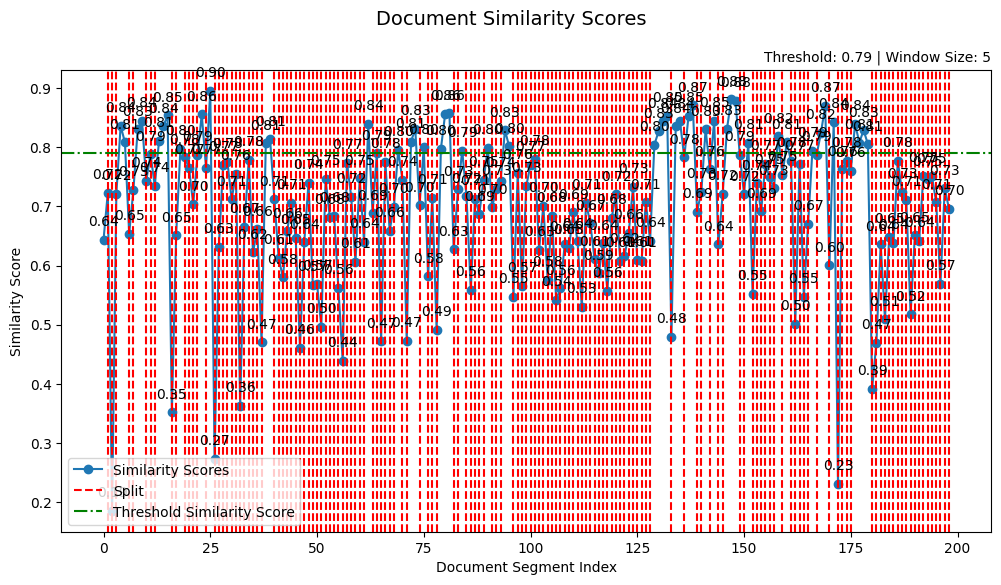

In [19]:
from langchain_community.embeddings import HuggingFaceEmbeddings 
from semantic_router.splitters import RollingWindowSplitter
from langchain.document_loaders import TextLoader
from semantic_router.encoders import HuggingFaceEncoder

loader = TextLoader("data/vi.wikipedia.org_wiki_V%C4%83n_Mi%E1%BA%BFu_%E2%80%93_Qu%E1%BB%91c_T%E1%BB%AD_Gi%C3%A1m/content.md")
docs = loader.load()

texts = [doc.page_content.lower() for doc in docs]

encoder = HuggingFaceEncoder(
    model_name="google/embeddinggemma-300m",
    device="cpu"
)
encoder.score_threshold = 0.79

splitter = RollingWindowSplitter(
    encoder=encoder,
    min_split_tokens=100,
    max_split_tokens=400,
    window_size=5,  
    plot_splits=True,
    dynamic_threshold=False,
)

splits = splitter(texts)

In [20]:
splitter.print(splits)

Split 1, tokens 110, triggered by: 0.72
"quốc tử giám" đổi hướng tới đây. đối với các định nghĩa khác, xem quốc tử giám (định hướng). khuê văn các - biểu tượng của thủ đô hà nội. đây là nơi học sinh thường hay chụp ảnh trong những lễ tốt nghiệp
----------------------------------------------------------------------------------------


Split 2, tokens 544, triggered by: 0.19
văn miếu – quốc tử giám là quần thể di tích đa dạng, phong phú hàng đầu của thành phố hà nội, nằm ở phía nam kinh thành thăng long. quần thể kiến trúc văn miếu – quốc tử giám bao gồm: hồ văn, khu văn miếu – quốc tử giám và vườn giám, mà kiến trúc chủ thể là văn miếu (chữ hán: 文廟) - nơi thờ khổng tử, và quốc tử giám (chữ hán: 國子監) - trường đại học đầu tiên của việt nam. khu văn miếu – quốc tử giám có tường gạch vồ bao quanh, phía trong chia thành 5 lớp không gian với các kiến trúc khác nhau. mỗi lớp không gian đó được giới hạn bởi các tường gạch có 3 cửa để thông với nhau (gồm cửa chính giữa và hai cửa phụ hai bên). t

In [8]:
import os
from utils.split_data import split_data

FILEPATH_REL = "data/vi.wikipedia.org_wiki_V%C4%83n_Mi%E1%BA%BFu_%E2%80%93_Qu%E1%BB%91c_T%E1%BB%AD_Gi%C3%A1m/content.md"
chunks = split_data(FILEPATH_REL)
print(chunks)

[Document(metadata={'source': 'data/vi.wikipedia.org_wiki_V%C4%83n_Mi%E1%BA%BFu_%E2%80%93_Qu%E1%BB%91c_T%E1%BB%AD_Gi%C3%A1m/content.md', 'destination': 'Văn miếu Quốc Tử Giám', 'province': 'Hà Nội', 'type': 'di tích lịch sử'}, page_content='"Quốc Tử Giám" đổi hướng tới đây. Đối với các định nghĩa khác, xem Quốc Tử Giám (định hướng).\n\nKhuê Văn Các - biểu tượng của Thủ đô Hà Nội. Đây là nơi học sinh thường hay chụp ảnh trong những lễ tốt nghiệp\nVăn Miếu – Quốc Tử Giám là quần thể di tích đa dạng, phong phú hàng đầu của thành phố Hà Nội, nằm ở phía Nam kinh thành Thăng Long. Quần thể kiến trúc Văn Miếu – Quốc Tử Giám bao gồm: hồ Văn, khu Văn Miếu – Quốc Tử Giám và vườn Giám, mà kiến trúc chủ thể là Văn miếu (chữ Hán: 文廟) - nơi thờ Khổng Tử, và Quốc tử giám (chữ Hán: 國子監) - trường đại học đầu tiên của Việt Nam. Khu Văn Miếu – Quốc Tử Giám có tường gạch vồ bao quanh, phía trong chia thành 5 lớp không gian với các kiến trúc khác nhau. Mỗi lớp không gian đó được giới hạn bởi các tường gạch

In [9]:
print(len(chunks))

24
